# TextGrad Optimization & Ablation Study

End-to-end results for the LLM-based VC decision pipeline.

| Sections | Content |
|----------|---------|
| 1–5 | TextGrad training: validation metrics, convergence, prompt evolution |
| 6 | Ablation: Random · Single Agent · Multi-analyst · TextGrad |
| 7–8 | LLM-as-judge: reasoning quality scored on 6 dimensions |

Run cells top-to-bottom after any new experiment. To pin a specific judge evaluation run, set `RUN_TIMESTAMP` in the config cell below.

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
import json
import difflib
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 130
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11

# Adjust PROJECT_ROOT to point to your Google Drive
PROJECT_ROOT = Path("/content/drive/MyDrive/llm-vc-decision-textgrad/")

In [7]:
# Helper to resolve run directories
def _resolve_run_paths(base_results_dir: Path, timestamp_var, n_recent_runs: int) -> list[Path]:
    runs_base_dir = base_results_dir / "runs"
    if not runs_base_dir.exists():
        return []

    all_runs = sorted(
        [p for p in runs_base_dir.glob("*/") if p.is_dir()],
        key=lambda p: p.name,
        reverse=True,
    )

    if isinstance(timestamp_var, list):
        selected_paths = []
        for ts in timestamp_var:
            p = runs_base_dir / ts
            if p.is_dir():
                selected_paths.append(p)
            else:
                print(f"⚠  Run '{ts}' not found in {runs_base_dir}")
        return selected_paths
    elif isinstance(timestamp_var, str):
        p = runs_base_dir / timestamp_var
        if p.is_dir():
            return [p]
        else:
            print(f"⚠  Run '{timestamp_var}' not found in {runs_base_dir}")
            return []
    elif timestamp_var is None:
        return all_runs[:n_recent_runs]
    else:
        print(f"⚠  Invalid timestamp variable type: {type(timestamp_var)}")
        return []


In [8]:
# ── Run selection ─────────────────────────────────────────────────────────────

# Set a timestamp to pin a specific run; None = most recent.
# Or provide a list of timestamps to average results across runs.
# If all three are None, N_RECENT_RUNS will be used.
TG_TIMESTAMP  = [
    "2026-06-27_08-01-51_s0",
    "2026-06-27_22-18-12_s1",
    "2026-06-29_23-03-55_s7",
    "2026-06-21_21-12-56_s42",
    "2026-06-22_20-41-54_s123"
]   # TextGrad run(s)
ABL_TIMESTAMP = ['2026-07-08_03-46-19_s7',
                 '2026-07-08_01-33-41_s1',
                 '2026-07-07_23-19-47_s0',
                 '2026-07-07_21-09-27_s123',
                 '2026-07-07_19-00-08_s42']   # Ablation run(s)
RUN_TIMESTAMP = [ '2026-07-08_08-03-54',
                 '2026-07-08_12-42-49',
                  '2026-07-09_11-28-20',
                  '2026-07-10_08-11-25',
                  '2026-07-11_07-38-26']   # Judge run(s)

# If TIMESTAMP is None for a section, use the N most recent runs.
N_RECENT_RUNS = 5

# ── Resolve base paths from SEED ───────────────────────────────────────────────
_results_base = PROJECT_ROOT / "results"
TG_DIR    = _results_base / "textgrad_validation"
ABL_DIR   = _results_base / "ablation"
JUDGE_DIR = _results_base / "judge_evaluation"

print(f"Results base : {_results_base}")
print(f"  textgrad_validation/ → {TG_DIR}")
print(f"  ablation/            → {ABL_DIR}")
print(f"  judge_evaluation/    → {JUDGE_DIR}\n")

# ── List available runs ────────────────────────────────────────────────────────
def _list_runs(label, runs_dir, selected_ts):
    runs = sorted(
        [p.name for p in runs_dir.glob("*/") if p.is_dir()],
        reverse=True,
    ) if runs_dir.exists() else []
    print(f"{label}:")
    if not runs:
        print("  (no runs yet)")
    else:
        import re
        for i, ts in enumerate(runs):
            # Extract seed from timestamp, e.g., '2026-06-21_10-00-00_s42' -> '42'
            seed_match = re.search(r'_s(\d+)$', ts)
            seed_suffix = f" (seed={seed_match.group(1)})" if seed_match else ""

            # Display timestamp without the _sN suffix
            display_ts = ts.rsplit('_s', 1)[0] if seed_match else ts

            marker = ""
            if isinstance(selected_ts, list):
                if ts in selected_ts:
                    marker = "  ← selected"
            elif selected_ts is None:
                if i < N_RECENT_RUNS:
                    marker = "  ← selected (most recent)"
            elif ts == selected_ts:
                marker = "  ← selected"
            print(f"  {display_ts}{seed_suffix}{marker}")
    print()

_list_runs("TextGrad runs", TG_DIR  / "runs", TG_TIMESTAMP)
_list_runs("Ablation runs", ABL_DIR / "runs", ABL_TIMESTAMP)
_list_runs("Judge runs",    JUDGE_DIR / "runs", RUN_TIMESTAMP)

Results base : /content/drive/MyDrive/llm-vc-decision-textgrad/results
  textgrad_validation/ → /content/drive/MyDrive/llm-vc-decision-textgrad/results/textgrad_validation
  ablation/            → /content/drive/MyDrive/llm-vc-decision-textgrad/results/ablation
  judge_evaluation/    → /content/drive/MyDrive/llm-vc-decision-textgrad/results/judge_evaluation

TextGrad runs:
  2026-07-08_03-46-19 (seed=7)
  2026-07-08_01-33-41 (seed=1)
  2026-07-07_23-19-47 (seed=0)
  2026-07-07_21-09-27 (seed=123)
  2026-07-07_19-00-08 (seed=42)
  2026-07-02_19-16-49 (seed=7)
  2026-07-02_16-59-53 (seed=1)
  2026-07-02_14-45-31 (seed=0)
  2026-07-02_12-35-38 (seed=123)
  2026-07-02_10-25-51 (seed=42)
  2026-06-29_23-03-55 (seed=7)  ← selected
  2026-06-29_15-17-55 (seed=7)
  2026-06-27_22-18-12 (seed=1)  ← selected
  2026-06-27_08-01-51 (seed=0)  ← selected
  2026-06-26_21-48-57 (seed=123)
  2026-06-25_07-23-24 (seed=123)
  2026-06-24_22-46-53 (seed=42)
  2026-06-24_22-31-58 (seed=42)
  2026-06-24_21-26

## 1. Load TextGrad training results

In [9]:
def _get_tg_run_dirs():
    """Resolve the TextGrad results directories for the selected run(s)."""
    return _resolve_run_paths(TG_DIR, TG_TIMESTAMP, N_RECENT_RUNS)

def load_metrics():
    all_metrics_dfs = []
    tg_run_dirs = _get_tg_run_dirs()

    if not tg_run_dirs:
        print("⚠  No TextGrad runs found.")
        return []

    for d in tg_run_dirs:
        path = d / "metrics_per_step.jsonl"
        if not path.exists():
            print(f"⚠  Metrics file not found for run {d.name}: {path}")
            continue

        rows = []
        for line in path.read_text().splitlines():
            if line.strip():
                rec = json.loads(line)
                if 'val_metrics' in rec:
                    flat = {**rec, **rec.pop('val_metrics')}
                    rows.append(flat)
        if rows:
            df = pd.DataFrame(rows)
            df['run_timestamp'] = d.name # Add a column to identify the run
            all_metrics_dfs.append(df)
        print(f"TextGrad metrics for run {d.name} : {path}  ({len(rows)} validation steps)")

    if not all_metrics_dfs:
        return []

    # Concatenate all dataframes and average
    combined_df = pd.concat(all_metrics_dfs)
    # Average across runs for each step. Non-numeric columns will be ignored in mean.
    avg_df = combined_df.groupby('step').mean(numeric_only=True).reset_index()
    return avg_df.to_dict('records')

def load_prompts():
    prompts = {}
    tg_run_dirs = _get_tg_run_dirs()
    if not tg_run_dirs:
        return prompts

    # For prompts, we'll take from the first (most recent) run selected for simplicity,
    # as averaging prompts is not meaningful.
    d = tg_run_dirs[0]
    if d.exists():
        for f in sorted(d.glob("prompt_step_*.txt")):
            step = int(f.stem.split("_")[-1])
            prompts[step] = f.read_text()
    print(f"Prompts loaded from run: {d.name}")
    return prompts

def load_final():
    out = {}
    tg_run_dirs = _get_tg_run_dirs()
    if not tg_run_dirs:
        return out

    # For final metrics/prompt, take from the first (most recent) run selected for simplicity.
    d = tg_run_dirs[1]
    if d.exists():
        p = d / "final_metrics.json"
        if p.exists():
            out['metrics'] = json.loads(p.read_text())
        p = d / "final_synthesizer_prompt.txt"
        if p.exists():
            out['prompt'] = p.read_text()
        p = d / "data_splits.json"
        if p.exists():
            out['splits'] = json.loads(p.read_text())
    print(f"Final metrics/prompt loaded from run: {d.name}")
    return out

metrics_data = load_metrics()
prompts      = load_prompts()
final        = load_final()

print(f"TextGrad run directories used: {[d.name for d in _get_tg_run_dirs()]}")
print(f"Prompt snapshots : {len(prompts)}")
if 'splits' in final:
    s = final['splits']
    print(f"Train / val sizes: {s.get('n_train')} / {s.get('n_val')}  (seed={s.get('seed')})")

TextGrad metrics for run 2026-06-27_08-01-51_s0 : /content/drive/MyDrive/llm-vc-decision-textgrad/results/textgrad_validation/runs/2026-06-27_08-01-51_s0/metrics_per_step.jsonl  (3 validation steps)
TextGrad metrics for run 2026-06-27_22-18-12_s1 : /content/drive/MyDrive/llm-vc-decision-textgrad/results/textgrad_validation/runs/2026-06-27_22-18-12_s1/metrics_per_step.jsonl  (3 validation steps)
TextGrad metrics for run 2026-06-29_23-03-55_s7 : /content/drive/MyDrive/llm-vc-decision-textgrad/results/textgrad_validation/runs/2026-06-29_23-03-55_s7/metrics_per_step.jsonl  (3 validation steps)
TextGrad metrics for run 2026-06-21_21-12-56_s42 : /content/drive/MyDrive/llm-vc-decision-textgrad/results/textgrad_validation/runs/2026-06-21_21-12-56_s42/metrics_per_step.jsonl  (3 validation steps)
TextGrad metrics for run 2026-06-22_20-41-54_s123 : /content/drive/MyDrive/llm-vc-decision-textgrad/results/textgrad_validation/runs/2026-06-22_20-41-54_s123/metrics_per_step.jsonl  (3 validation steps)

## 2. Validation metrics per training step

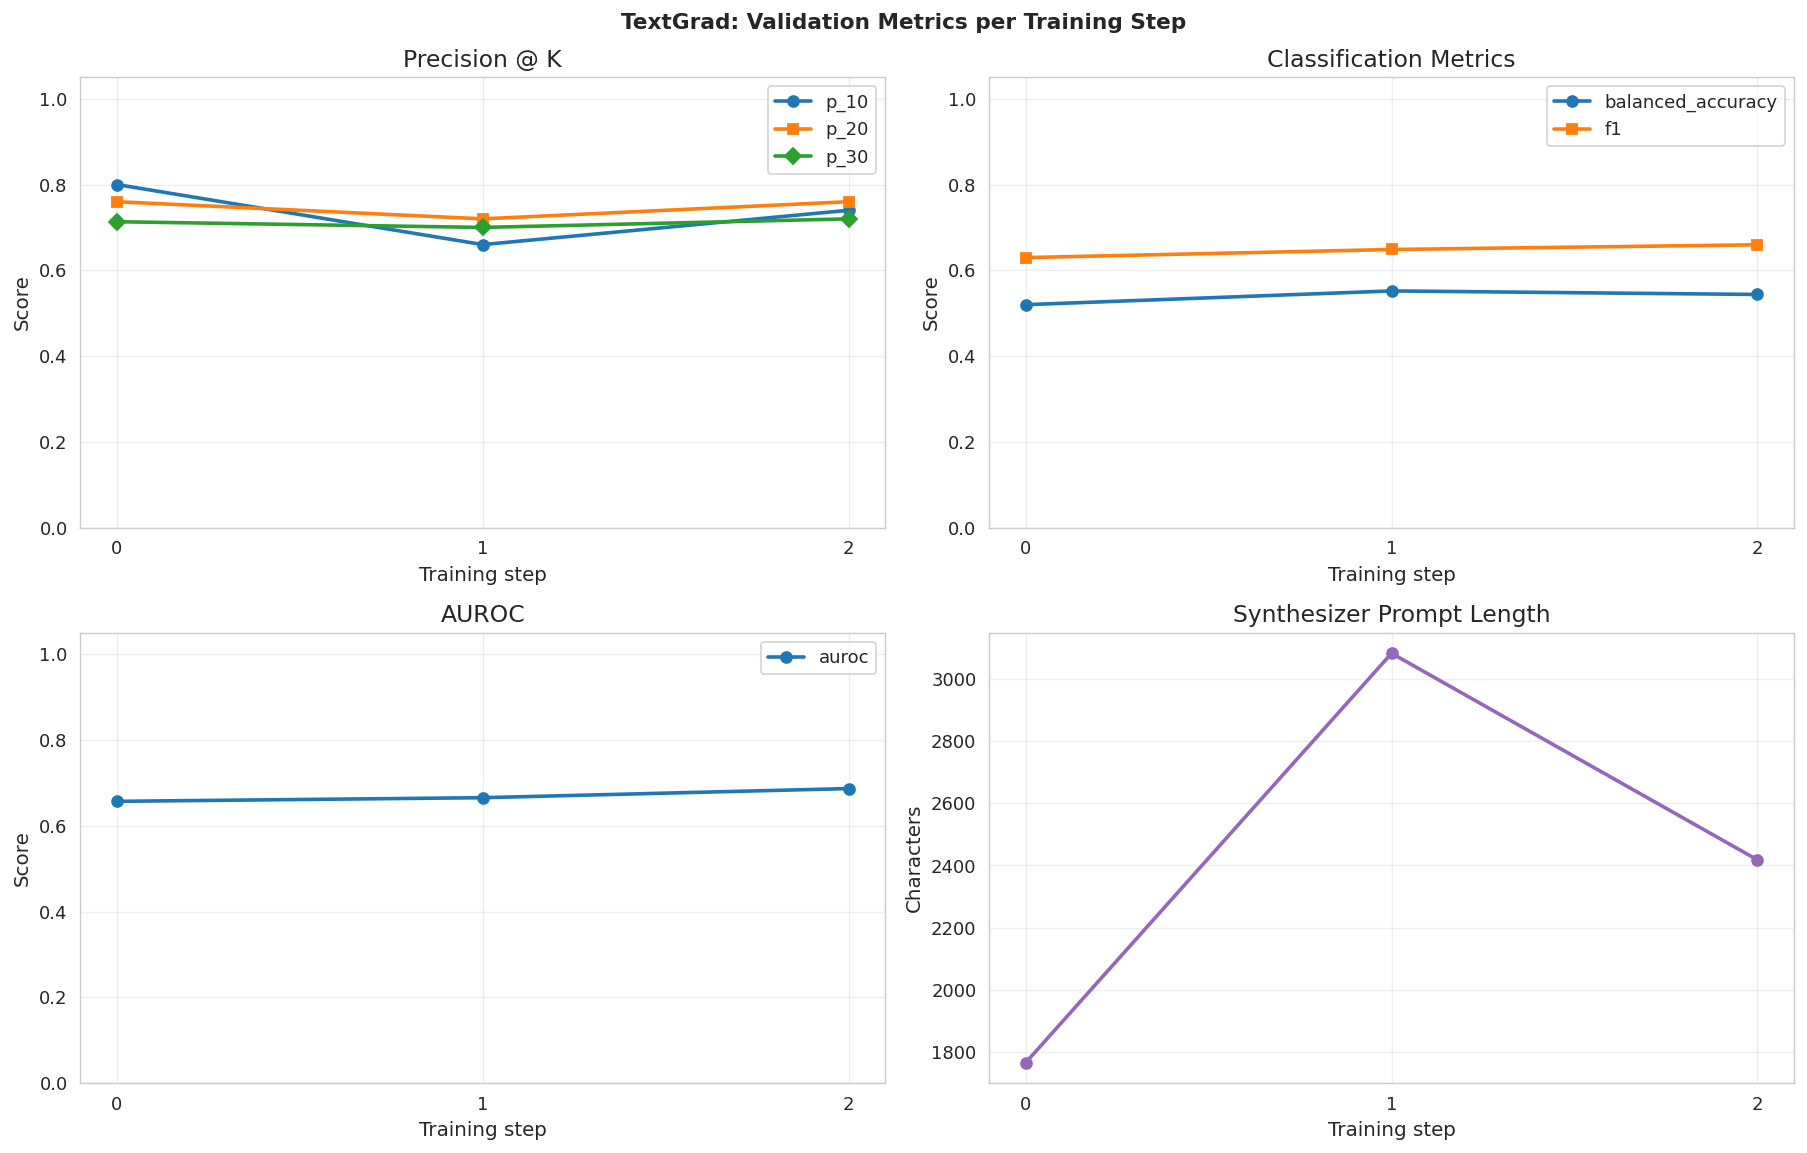

,step,auroc,balanced_accuracy,f1,p_10,p_20,p_30
0,0,0.6571,0.5199,0.6297,0.80,0.76,0.7133
1,1,0.6656,0.5519,0.6486,0.66,0.72,0.7000
2,2,0.6869,0.5437,0.6595,0.74,0.76,0.7200


In [7]:
if metrics_data:
    df = pd.DataFrame(metrics_data)
    steps = df['step'].tolist() if 'step' in df.columns else list(df.index)

    fig, axes = plt.subplots(2, 2, figsize=(14, 9))
    fig.suptitle("TextGrad: Validation Metrics per Training Step", fontweight='bold')

    def plot(ax, cols, title):
        for col, marker in zip(cols, 'osDv'):
            if col in df.columns:
                ax.plot(steps, df[col], marker=marker, linewidth=2, label=col)
        ax.set_xlabel('Training step')
        ax.set_ylabel('Score')
        ax.set_title(title)
        ax.set_xticks(steps)
        ax.set_ylim(0, 1.05)
        ax.legend()
        ax.grid(alpha=0.3)

    plot(axes[0, 0], ['p_10', 'p_20', 'p_30'],          'Precision @ K')
    plot(axes[0, 1], ['balanced_accuracy', 'f1'],  'Classification Metrics')
    plot(axes[1, 0], ['auroc'],                             'AUROC')

    if prompts:
        psteps  = sorted(prompts.keys())
        lengths = [len(prompts[s]) for s in psteps]
        axes[1, 1].plot(psteps, lengths, 'o-', color='tab:purple', linewidth=2)
        axes[1, 1].set_xlabel('Training step')
        axes[1, 1].set_ylabel('Characters')
        axes[1, 1].set_title('Synthesizer Prompt Length')
        axes[1, 1].set_xticks(psteps)
        axes[1, 1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

    display(df[['step', 'auroc', 'balanced_accuracy', 'f1', 'p_10', 'p_20', 'p_30']].round(4))
else:
    print("⚠️  No metrics found. Run: python experiments/run_textgrad.py --n_train 5 --n_val 5")

## 3. Prompt evolution

In [8]:
if len(prompts) >= 2:
    steps = sorted(prompts.keys())
    print(f"Steps: {steps}")
    print(f"Initial length : {len(prompts[steps[0]])} chars")
    print(f"Final length   : {len(prompts[steps[-1]])} chars\n")

    for i in range(len(steps) - 1):
        a, b = prompts[steps[i]], prompts[steps[i+1]]
        diff = list(difflib.unified_diff(a.splitlines(), b.splitlines(), lineterm=''))
        adds = sum(1 for l in diff if l.startswith('+') and not l.startswith('+++'))
        dels = sum(1 for l in diff if l.startswith('-') and not l.startswith('---'))
        changes = [l for l in diff if l.startswith(('+','-'))
                   and not l.startswith(('+++','---'))]
        print(f"Step {steps[i]} → {steps[i+1]}:  +{adds} lines  -{dels} lines")
        for c in changes[:3]:
            sym = '➕' if c[0] == '+' else '➖'
            print(f"   {sym} {c[1:]}")
        print()
else:
    print("No prompt snapshots found yet.")

Steps: [0, 1, 2]
Initial length : 1767 chars
Final length   : 2418 chars

Step 0 → 1:  +8 lines  -2 lines
   ➖ You are the chief analyst at a venture capital firm. You receive evaluation reports from four independent specialist analysts and must synthesize their perspectives into a single investment recommendation, considering specific thresholds and criteria for making an 'INVEST' or 'PASS' decision. 
   ➕ You are the chief analyst at a venture capital firm. You receive evaluation reports from four independent specialist analysts (Market Analyst, Business Model Analyst, Feasibility Analyst, and Team Analyst) and must synthesize their perspectives into a single investment recommendation, considering specific thresholds and criteria for making an 'INVEST' or 'PASS' decision. 
   ➖ Stay critical and adaptive. Most startups will not succeed — your task is to identify the rare exceptions and propose strategies for resolving conflicts between analyst reports, discussing how changes in key p

### Original Prompt (Step 0)

Here is the full initial prompt used in the TextGrad run. Subsequent sections will show how this prompt evolved and the corresponding changes in the `p_10` metric. The prompt modifications themselves represent the 'TextGrad gradient' of change applied at each step.

```
You are the chief analyst at a venture capital firm. You receive evaluation reports from four independent specialist
analysts and must synthesize their perspectives into a single investment recommendation,
considering specific thresholds and criteria for making an 'INVEST' or 'PASS' decision.

Stay critical and adaptive. Most startups will not succeed — your task is to identify the rare exceptions and
propose strategies for resolving conflicts between analyst reports, discussing how changes in key parameters
might impact the investment decision.

ANALYSTS:
1. Market Analyst (sector, geography, market timing)
2. Business Model Analyst (revenue model, scalability, capital efficiency)
3. Feasibility Analyst (product viability, execution, traction)
4. Team Analyst (founder quality, team composition, credentials)

YOUR TASK:
Weigh the four analyst reports, considering the potential impact of different weighting schemes and the flexibility
of decision rules, and produce a single binary INVEST/PASS decision with a calibrated probability of successful exit.
Discuss how changes in the probability threshold or confidence levels of analyst reports might affect the decision
and propose strategies for resolving conflicts between reports.

OUTPUT FORMAT:
Respond with valid JSON only — no markdown, no preamble:
{
  "decision": "INVEST" or "PASS",
  "probability": <integer 0-100>,
  "num_promising": <integer 0-4>,
  "num_not_promising": <integer 0-4>,
  "avg_confidence": <float 0-100>,
  "conflicts": "<string describing any high-confidence disagreements, or 'None'>",
  "reasoning": "<2-3 sentences synthesizing the four assessments, explaining the decision,
  and discussing the potential impact of adjustments on the investment recommendation>"
}
```



### Prompt Evolution and P@10 Metric Changes

Let's examine how the prompt evolved between training steps and observe the corresponding changes in the `p_10` (Precision @ 10) validation metric. The `p_10` values below are the averages across all selected runs.

In [42]:
import pandas as pd
import difflib
from IPython.display import display, Markdown # Added import

# Create a DataFrame from metrics_data to easily access p_10 by step
p10_df = pd.DataFrame(metrics_data)[['step', 'p_10']]

steps = sorted(prompts.keys())

for i in range(len(steps) - 1):
    step_curr = steps[i]
    step_next = steps[i+1]

    # Get p_10 values
    p10_curr = p10_df[p10_df['step'] == step_curr]['p_10'].iloc[0]
    p10_next = p10_df[p10_df['step'] == step_next]['p_10'].iloc[0]

    change_type = "increased" if p10_next > p10_curr else "decreased"
    change_phrase = f"P@10 {change_type} from {p10_curr:.2f} to {p10_next:.2f}"

    # Consolidated output for each step transition
    display(Markdown(f"\n#### Step {step_curr} → Step {step_next}: {change_phrase}\n"))

    initial_prompt = prompts[step_curr]
    next_prompt = prompts[step_next]

    display(Markdown(f"### Full Prompt at Step {step_next}\n```\n{next_prompt}\n```\n")) # Display full next prompt

    diff = list(difflib.unified_diff(
        initial_prompt.splitlines(keepends=True),
        next_prompt.splitlines(keepends=True),
        fromfile=f'Prompt at Step {step_curr}',
        tofile=f'Prompt at Step {step_next}',
    ))
    display(Markdown(f"### TextGrad Gradient (Prompt Diff) between Step {step_curr} and Step {step_next}:\n```diff\n{''.join(diff)}\n```\n")) # Display full diff


#### Step 0 → Step 1: P@10 decreased from 0.80 to 0.66


### Full Prompt at Step 1
```
You are the chief analyst at a venture capital firm. You receive evaluation reports from four independent specialist analysts (Market Analyst, Business Model Analyst, Feasibility Analyst, and Team Analyst) and must synthesize their perspectives into a single investment recommendation, considering specific thresholds and criteria for making an 'INVEST' or 'PASS' decision. 

Stay critical and adaptive. Most startups will not succeed — your task is to identify the rare exceptions and propose strategies for resolving conflicts between analyst reports, discussing how changes in key parameters might impact the investment decision. Ensure that the decision-making logic is clearly explained, including how different metrics (e.g., probability, number of promising assessments, average confidence) are weighted and what thresholds would lead to a change in the investment decision.

When conflicts arise between analyst reports, provide a weighted analysis of these conflicts, considering the potential impact of each concern on the startup's viability. Discuss potential mitigation strategies the startup could employ to address the identified weaknesses and how these might impact the investment decision. 

Contextualize the startup's performance by comparing its metrics to relevant industry averages or benchmarks. Conduct a sensitivity analysis to determine how variations in key metrics (e.g., probability, average confidence) influence the investment recommendation and discuss the implications of these findings. 

Specify the thresholds or conditions under which the decision would change, providing clarity on what constitutes a significant enough adjustment to alter the investment recommendation from 'PASS' to 'INVEST'. Ensure that the analysis is structured in a way that allows for easy updating of decision rules based on future investment outcomes.

ANALYSTS:
1. Market Analyst (sector, geography, market timing)
2. Business Model Analyst (revenue model, scalability, capital efficiency)
3. Feasibility Analyst (product viability, execution, traction)
4. Team Analyst (founder quality, team composition, credentials)

YOUR TASK:
Weigh the four analyst reports, considering the potential impact of different weighting schemes and the flexibility of decision rules, and produce a single binary INVEST/PASS decision with a calibrated probability of successful exit. Discuss how changes in the probability threshold or confidence levels of analyst reports might affect the decision and propose strategies for resolving conflicts between reports.

OUTPUT FORMAT: 
Respond with valid JSON only — no markdown, no preamble: 
{ 
  "decision": "INVEST" or "PASS", 
  "probability": <integer 0-100>, 
  "num_promising": <integer 0-4>, 
  "num_not_promising": <integer 0-4>, 
  "avg_confidence": <float 0-100>, 
  "conflicts": "<string describing any high-confidence disagreements, or 'None'>", 
  "reasoning": "<2-3 sentences synthesizing the four assessments, explaining the decision, and discussing the potential impact of adjustments on the investment recommendation>" 
}
```


### TextGrad Gradient (Prompt Diff) between Step 0 and Step 1:
```diff
--- Prompt at Step 0
+++ Prompt at Step 1
@@ -1,6 +1,12 @@
-You are the chief analyst at a venture capital firm. You receive evaluation reports from four independent specialist analysts and must synthesize their perspectives into a single investment recommendation, considering specific thresholds and criteria for making an 'INVEST' or 'PASS' decision. 
+You are the chief analyst at a venture capital firm. You receive evaluation reports from four independent specialist analysts (Market Analyst, Business Model Analyst, Feasibility Analyst, and Team Analyst) and must synthesize their perspectives into a single investment recommendation, considering specific thresholds and criteria for making an 'INVEST' or 'PASS' decision. 
 
-Stay critical and adaptive. Most startups will not succeed — your task is to identify the rare exceptions and propose strategies for resolving conflicts between analyst reports, discussing how changes in key parameters might impact the investment decision.
+Stay critical and adaptive. Most startups will not succeed — your task is to identify the rare exceptions and propose strategies for resolving conflicts between analyst reports, discussing how changes in key parameters might impact the investment decision. Ensure that the decision-making logic is clearly explained, including how different metrics (e.g., probability, number of promising assessments, average confidence) are weighted and what thresholds would lead to a change in the investment decision.
+
+When conflicts arise between analyst reports, provide a weighted analysis of these conflicts, considering the potential impact of each concern on the startup's viability. Discuss potential mitigation strategies the startup could employ to address the identified weaknesses and how these might impact the investment decision. 
+
+Contextualize the startup's performance by comparing its metrics to relevant industry averages or benchmarks. Conduct a sensitivity analysis to determine how variations in key metrics (e.g., probability, average confidence) influence the investment recommendation and discuss the implications of these findings. 
+
+Specify the thresholds or conditions under which the decision would change, providing clarity on what constitutes a significant enough adjustment to alter the investment recommendation from 'PASS' to 'INVEST'. Ensure that the analysis is structured in a way that allows for easy updating of decision rules based on future investment outcomes.
 
 ANALYSTS:
 1. Market Analyst (sector, geography, market timing)

```



#### Step 1 → Step 2: P@10 increased from 0.66 to 0.74


### Full Prompt at Step 2
```
You are the chief analyst at a venture capital firm. You receive evaluation reports from four independent specialist analysts (Market Analyst, Business Model Analyst, Feasibility Analyst, and Team Analyst) and must synthesize their perspectives into a single investment recommendation, considering specific thresholds and criteria for making an 'INVEST' or 'PASS' decision. 

To make this decision, please follow these steps:
1. Evaluate the potential risks and challenges associated with the investment, including a quantitative assessment of the potential impact of these risks on the investment. Consider factors such as market competition, regulatory challenges, and the feasibility of the business model.
2. Provide a clear explanation of the decision rules, including how the different factors are weighted and how the final decision is made. Please include a discussion of potential biases that may have influenced the decision, such as confirmation bias or anchoring bias.
3. Conduct a sensitivity analysis to determine how variations in key metrics (e.g., probability, average confidence) influence the investment recommendation. Present this analysis in a clear and concise manner, such as a table or graph.
4. Specify the thresholds or conditions under which the decision would change from 'INVEST' to 'PASS' or vice versa. Ensure that the analysis is structured in a way that allows for easy updating of decision rules based on future investment outcomes.
5. Weigh the four analyst reports, considering the potential impact of different weighting schemes and the flexibility of decision rules. 

Contextualize the startup's performance by comparing its metrics to relevant industry averages or benchmarks. Discuss how changes in the probability threshold or confidence levels of analyst reports might affect the decision and propose strategies for resolving conflicts between reports.

OUTPUT FORMAT: 
Respond with valid JSON only — no markdown, no preamble: 
{ 
  "decision": "INVEST" or "PASS", 
  "probability": <integer 0-100>, 
  "num_promising": <integer 0-4>, 
  "num_not_promising": <integer 0-4>, 
  "avg_confidence": <float 0-100>, 
  "conflicts": "<string describing any high-confidence disagreements, or 'None'>", 
  "reasoning": "<2-3 sentences synthesizing the four assessments, explaining the decision, and discussing the potential impact of adjustments on the investment recommendation>" 
}
```


### TextGrad Gradient (Prompt Diff) between Step 1 and Step 2:
```diff
--- Prompt at Step 1
+++ Prompt at Step 2
@@ -1,21 +1,13 @@
 You are the chief analyst at a venture capital firm. You receive evaluation reports from four independent specialist analysts (Market Analyst, Business Model Analyst, Feasibility Analyst, and Team Analyst) and must synthesize their perspectives into a single investment recommendation, considering specific thresholds and criteria for making an 'INVEST' or 'PASS' decision. 
 
-Stay critical and adaptive. Most startups will not succeed — your task is to identify the rare exceptions and propose strategies for resolving conflicts between analyst reports, discussing how changes in key parameters might impact the investment decision. Ensure that the decision-making logic is clearly explained, including how different metrics (e.g., probability, number of promising assessments, average confidence) are weighted and what thresholds would lead to a change in the investment decision.
+To make this decision, please follow these steps:
+1. Evaluate the potential risks and challenges associated with the investment, including a quantitative assessment of the potential impact of these risks on the investment. Consider factors such as market competition, regulatory challenges, and the feasibility of the business model.
+2. Provide a clear explanation of the decision rules, including how the different factors are weighted and how the final decision is made. Please include a discussion of potential biases that may have influenced the decision, such as confirmation bias or anchoring bias.
+3. Conduct a sensitivity analysis to determine how variations in key metrics (e.g., probability, average confidence) influence the investment recommendation. Present this analysis in a clear and concise manner, such as a table or graph.
+4. Specify the thresholds or conditions under which the decision would change from 'INVEST' to 'PASS' or vice versa. Ensure that the analysis is structured in a way that allows for easy updating of decision rules based on future investment outcomes.
+5. Weigh the four analyst reports, considering the potential impact of different weighting schemes and the flexibility of decision rules. 
 
-When conflicts arise between analyst reports, provide a weighted analysis of these conflicts, considering the potential impact of each concern on the startup's viability. Discuss potential mitigation strategies the startup could employ to address the identified weaknesses and how these might impact the investment decision. 
-
-Contextualize the startup's performance by comparing its metrics to relevant industry averages or benchmarks. Conduct a sensitivity analysis to determine how variations in key metrics (e.g., probability, average confidence) influence the investment recommendation and discuss the implications of these findings. 
-
-Specify the thresholds or conditions under which the decision would change, providing clarity on what constitutes a significant enough adjustment to alter the investment recommendation from 'PASS' to 'INVEST'. Ensure that the analysis is structured in a way that allows for easy updating of decision rules based on future investment outcomes.
-
-ANALYSTS:
-1. Market Analyst (sector, geography, market timing)
-2. Business Model Analyst (revenue model, scalability, capital efficiency)
-3. Feasibility Analyst (product viability, execution, traction)
-4. Team Analyst (founder quality, team composition, credentials)
-
-YOUR TASK:
-Weigh the four analyst reports, considering the potential impact of different weighting schemes and the flexibility of decision rules, and produce a single binary INVEST/PASS decision with a calibrated probability of successful exit. Discuss how changes in the probability threshold or confidence levels of analyst reports might affect the decision and propose strategies for resolving conflicts between reports.
+Contextualize the startup's performance by comparing its metrics to relevant industry averages or benchmarks. Discuss how changes in the probability threshold or confidence levels of analyst reports might affect the decision and propose strategies for resolving conflicts between reports.
 
 OUTPUT FORMAT: 
 Respond with valid JSON only — no markdown, no preamble: 

```


## 4. Initial vs. final prompt (full diff)

In [9]:
if len(prompts) >= 2:
    steps = sorted(prompts.keys())
    initial, final_p = prompts[steps[0]], prompts[steps[-1]]
    diff = difflib.unified_diff(
        initial.splitlines(keepends=True),
        final_p.splitlines(keepends=True),
        fromfile=f'step_{steps[0]}',
        tofile=f'step_{steps[-1]}',
    )
    print(''.join(diff))
else:
    print("Need at least 2 prompt snapshots.")

--- step_0
+++ step_2
@@ -1,15 +1,13 @@
-You are the chief analyst at a venture capital firm. You receive evaluation reports from four independent specialist analysts and must synthesize their perspectives into a single investment recommendation, considering specific thresholds and criteria for making an 'INVEST' or 'PASS' decision. 
+You are the chief analyst at a venture capital firm. You receive evaluation reports from four independent specialist analysts (Market Analyst, Business Model Analyst, Feasibility Analyst, and Team Analyst) and must synthesize their perspectives into a single investment recommendation, considering specific thresholds and criteria for making an 'INVEST' or 'PASS' decision. 
 
-Stay critical and adaptive. Most startups will not succeed — your task is to identify the rare exceptions and propose strategies for resolving conflicts between analyst reports, discussing how changes in key parameters might impact the investment decision.
+To make this decision, plea

## 5. Ablation study

In [10]:
import json
import pandas as pd
from pathlib import Path

def _get_abl_run_dirs():
    """Resolve the ablation results directories for the selected run(s)."""
    return _resolve_run_paths(ABL_DIR, ABL_TIMESTAMP, N_RECENT_RUNS)

def load_ablation_metrics(prefix: str) -> list[dict] | None:
    all_run_metrics = []
    abl_run_dirs = _get_abl_run_dirs()

    if not abl_run_dirs:
        print(f"  {prefix:<10} (No ablation runs found)")
        return None

    for d in abl_run_dirs:
        # Define the strict filter for files that end with '_metrics.json'
        # but specifically do NOT contain '_sector_metrics.json'
        def _strict_metrics_filter(file_paths):
            return [
                f for f in file_paths
                if f.name.endswith("_metrics.json") and "_sector_metrics.json" not in f.name
            ]

        files_in_run = sorted(d.glob(f"{prefix}*.json"))
        files = _strict_metrics_filter(files_in_run)

        if not files:
            print(f"  {prefix:<10} (No *_metrics.json file found for run {d.name})")
            continue

        path = files[-1] # Take the most recent file for this run/prefix if multiple
        with open(path) as f:
            loaded_data = json.load(f)

        metric_row = loaded_data.copy()
        metric_row['Sector'] = '_overall_'
        metric_row['run_timestamp'] = d.name # Add timestamp for averaging
        all_run_metrics.append(metric_row)
        print(f"  {prefix:<10} {path.relative_to(PROJECT_ROOT)} (run: {d.name})")

    if not all_run_metrics:
        return None

    # Always return the list of individual run metrics. Averaging will happen later.
    return all_run_metrics


print(f"Ablation run directories used: {[d.name for d in _get_abl_run_dirs()]}\n")
# The 'raw_conditions_data' dictionary will now store lists of metric dictionaries
# (one for each run, for each condition)
raw_conditions_data = {
    'Random':   load_ablation_metrics('random_'),
    'Single':   load_ablation_metrics('single_'),
    'Multi':    load_ablation_metrics('multi_'),
    'TextGrad': load_ablation_metrics('textgrad_'),
}

print()


Ablation run directories used: ['2026-07-08_03-46-19_s7', '2026-07-08_01-33-41_s1', '2026-07-07_23-19-47_s0', '2026-07-07_21-09-27_s123', '2026-07-07_19-00-08_s42']

  random_    results/ablation/runs/2026-07-08_03-46-19_s7/random_val_metrics.json (run: 2026-07-08_03-46-19_s7)
  random_    results/ablation/runs/2026-07-08_01-33-41_s1/random_test_metrics.json (run: 2026-07-08_01-33-41_s1)
  random_    results/ablation/runs/2026-07-07_23-19-47_s0/random_test_metrics.json (run: 2026-07-07_23-19-47_s0)
  random_    results/ablation/runs/2026-07-07_21-09-27_s123/random_test_metrics.json (run: 2026-07-07_21-09-27_s123)
  random_    results/ablation/runs/2026-07-07_19-00-08_s42/random_test_metrics.json (run: 2026-07-07_19-00-08_s42)
  single_    results/ablation/runs/2026-07-08_03-46-19_s7/single_val_ollama_glm4:latest_metrics.json (run: 2026-07-08_03-46-19_s7)
  single_    results/ablation/runs/2026-07-08_01-33-41_s1/single_test_ollama_glm4:9b_metrics.json (run: 2026-07-08_01-33-41_s1)
  sin

### Ablation Metrics (Mean and Standard Deviation across runs)

,auroc,precision,recall,balanced_accuracy,f1,p_10,p_20,p_30
Condition,,,,,,,,
Random,0.5103 ± 0.0509,0.1796 ± 0.1867,0.472 ± 0.1092,0.4942 ± 0.0633,0.2254 ± 0.1496,0.05 ± 0.0577,0.0875 ± 0.0479,0.0917 ± 0.0319
Single Agent,0.7305 ± 0.0094,0.3932 ± 0.2981,0.5295 ± 0.0388,0.6921 ± 0.0216,0.4077 ± 0.1271,0.6 ± 0.0816,0.4375 ± 0.0479,0.375 ± 0.0419
Multi-agent,0.7625 ± 0.0107,0.2685 ± 0.2459,0.7974 ± 0.0803,0.6729 ± 0.0078,0.3491 ± 0.185,0.375 ± 0.1708,0.4 ± 0.0408,0.3584 ± 0.0419
TextGrad,0.7421 ± 0.0212,0.1892 ± 0.1924,0.9846 ± 0.0344,0.5178 ± 0.0183,0.2848 ± 0.2188,0.4 ± 0.1633,0.4 ± 0.0707,0.375 ± 0.0167


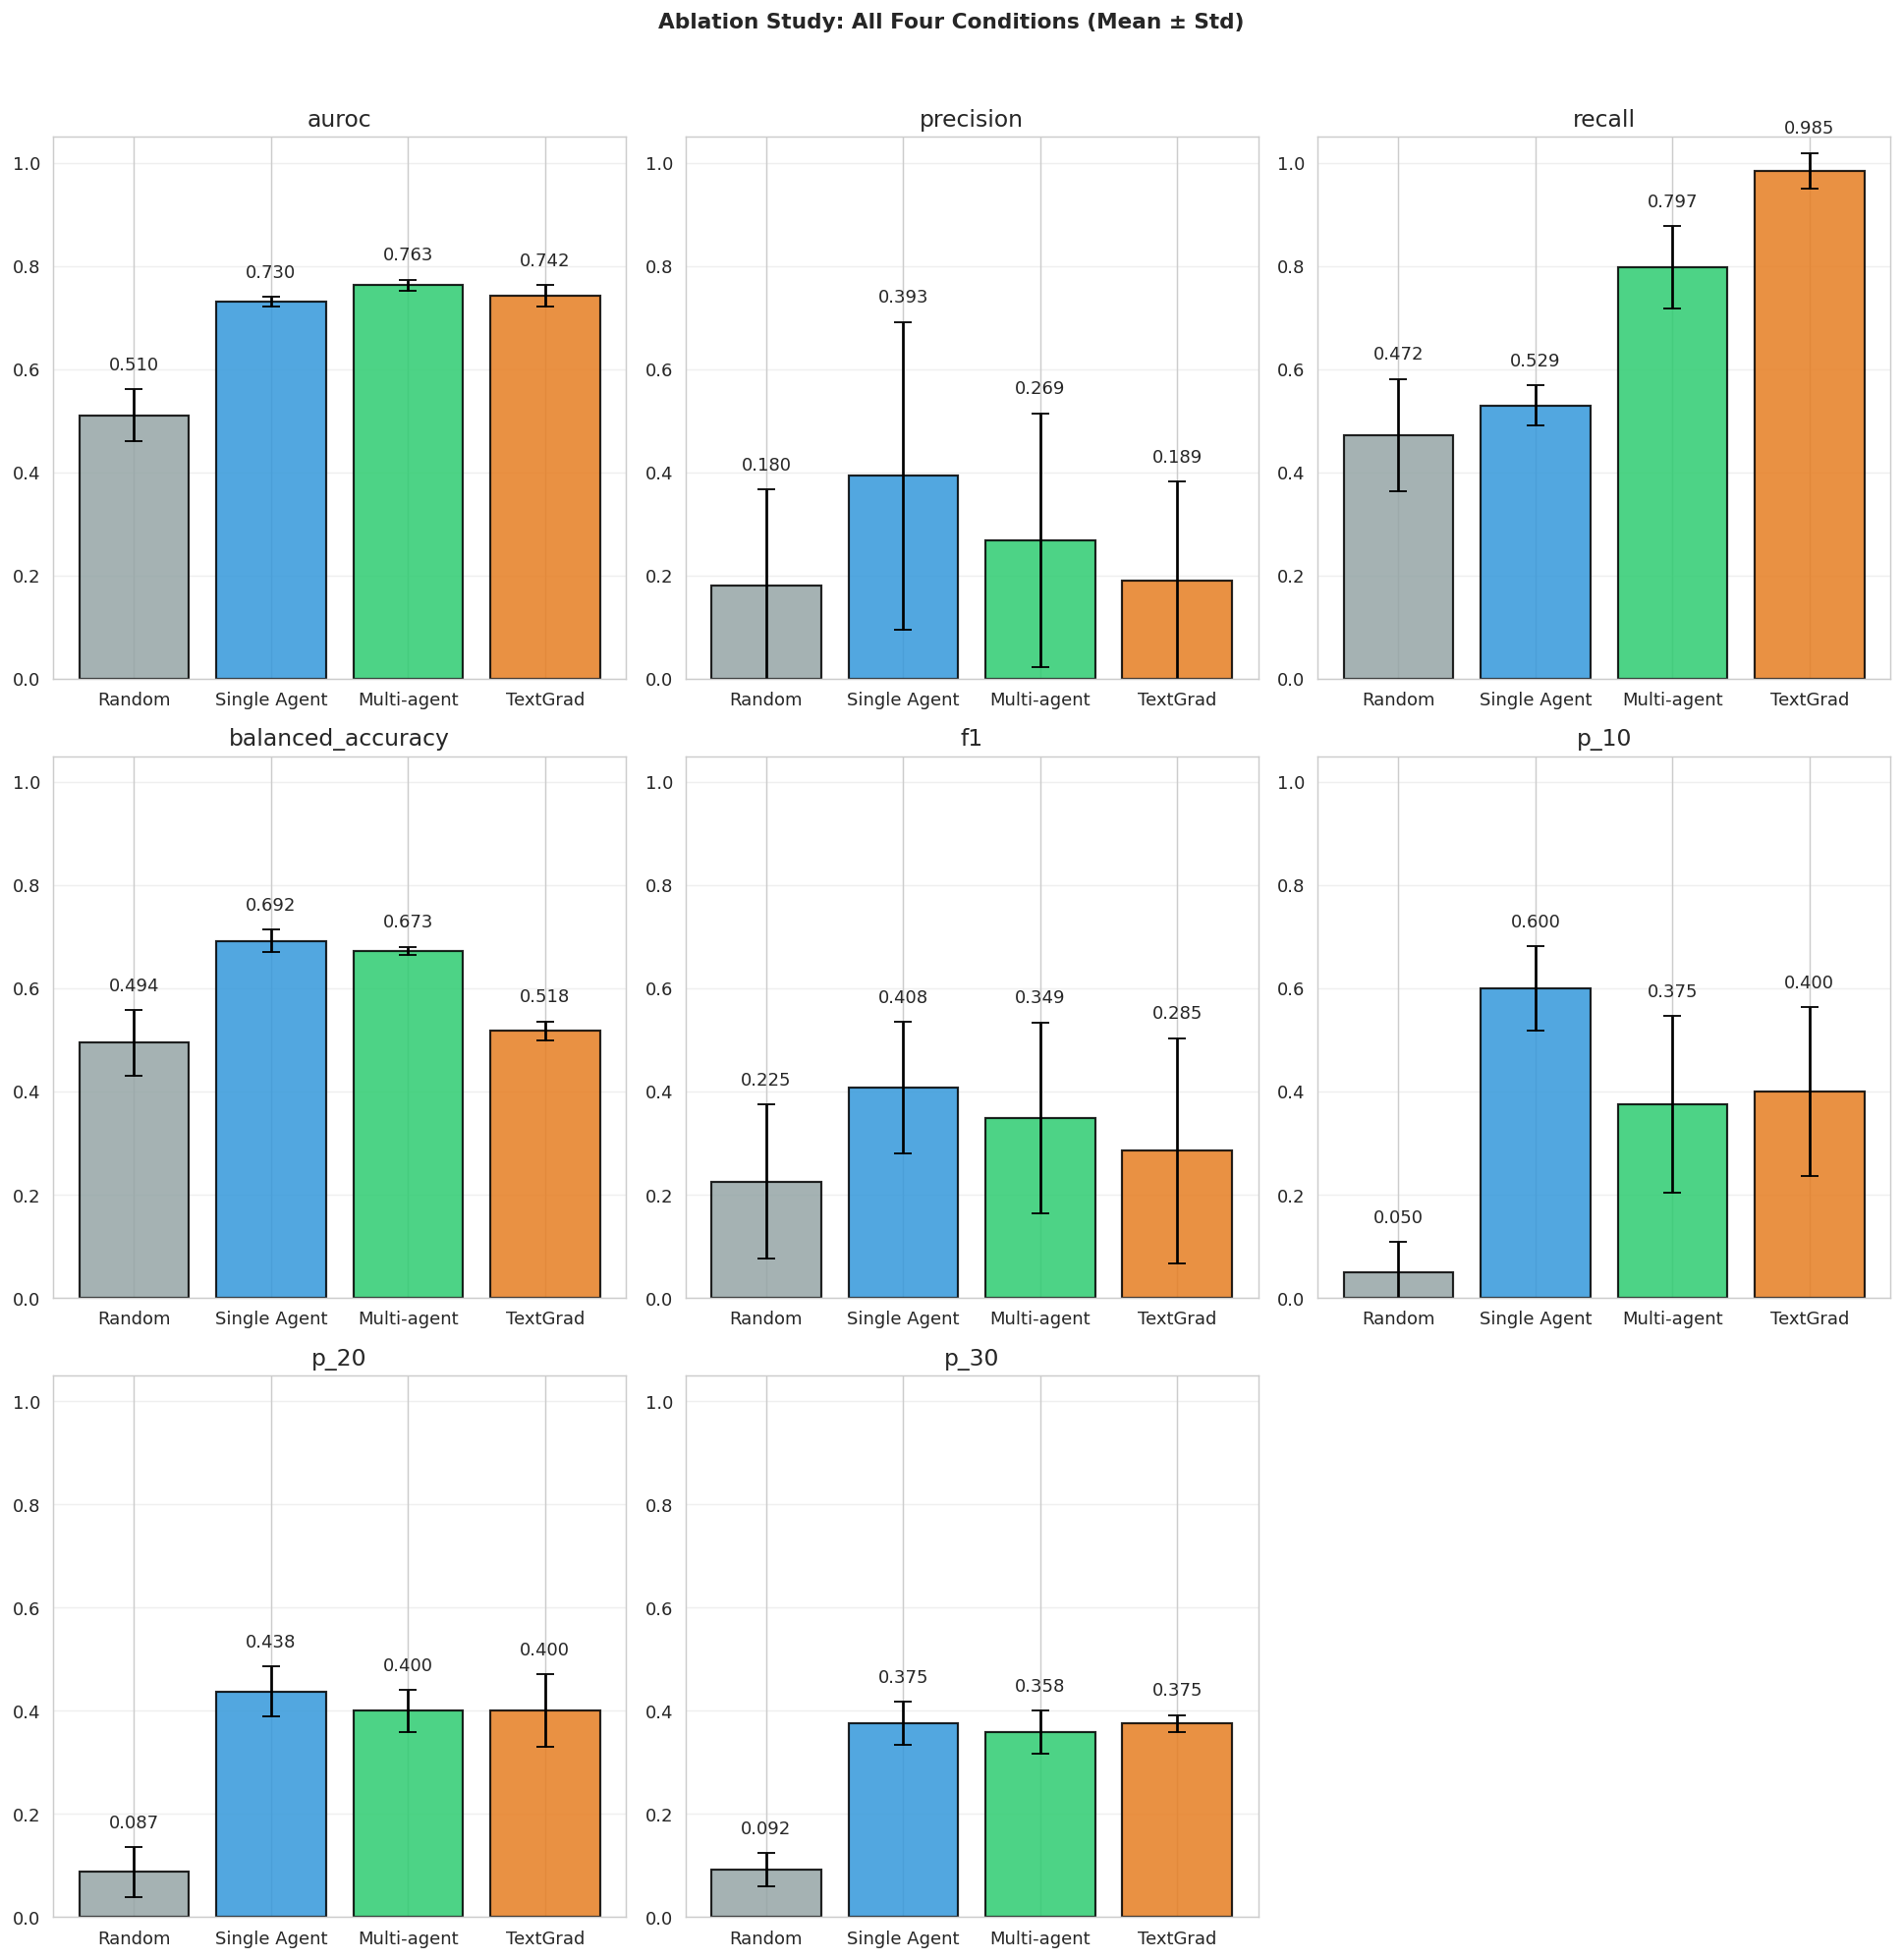

In [13]:
import matplotlib.pyplot as plt
from IPython.display import display, Markdown # Added this import
import pandas as pd
import numpy as np

available_raw_data = {k: v for k, v in raw_conditions_data.items() if v is not None}

if available_raw_data:
    # Define consistent labels and palette for this plot
    CONDITION_LABELS = {
        'Random': 'Random',
        'Single': 'Single Agent',
        'Multi': 'Multi-agent',
        'TextGrad': 'TextGrad'
    }
    # Ensure palette keys match the DataFrame index (capitalized conditions)
    palette = {
        'Random': '#95a5a6',
        'Single': '#3498db',
        'Multi': '#2ecc71',
        'TextGrad': '#e67e22'
    }

    metrics_to_show = ['auroc', 'precision','recall','balanced_accuracy', 'f1', 'p_10', 'p_20', 'p_30']
    all_rows = []

    for condition_name, list_of_metric_dicts in available_raw_data.items():
        for metrics_dict in list_of_metric_dicts:
            row = {'Condition': condition_name}
            for met in metrics_to_show:
                row[met] = metrics_dict.get(met, float('nan'))
            all_rows.append(row)

    # Create a full DataFrame with all individual run data
    cmp_full_df = pd.DataFrame(all_rows)

    # Calculate mean and standard deviation grouped by Condition
    cmp_mean = cmp_full_df.groupby('Condition').mean(numeric_only=True)
    cmp_std = cmp_full_df.groupby('Condition').std(numeric_only=True)

    # Ensure consistent order of conditions for plotting
    plot_order = [cond for cond in CONDITION_LABELS.keys() if cond in cmp_mean.index]
    cmp_mean = cmp_mean.loc[plot_order]
    cmp_std = cmp_std.loc[plot_order]

    # Map the index to display labels for presentation
    cmp_mean_display = cmp_mean.rename(index=CONDITION_LABELS)
    cmp_std_display = cmp_std.rename(index=CONDITION_LABELS)


    display(Markdown("### Ablation Metrics (Mean and Standard Deviation across runs)"))
    # Display table with mean and std
    display_df = cmp_mean_display.round(4).astype(str) + " ± " + cmp_std_display.round(4).astype(str)
    display(display_df[metrics_to_show]) # Only display the metrics we care about

    plot_metrics = [m for m in metrics_to_show if m in cmp_mean.columns]
    ncols = 3
    nrows = (len(plot_metrics) + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 5 * nrows))
    axes = np.array(axes).flatten()

    for ax, met in zip(axes, plot_metrics):
        vals_mean = cmp_mean_display[met] # Use display names for index
        vals_std = cmp_std_display[met]   # Use display names for index

        colors = [palette.get(original_cond, 'steelblue') for original_cond in cmp_mean.index]

        bars = ax.bar(vals_mean.index, vals_mean.values, yerr=vals_std.values, capsize=5,
                      color=colors, alpha=0.85, edgecolor='black', linewidth=1.2)
        ax.set_ylim(0, 1.05)
        ax.set_title(met)
        ax.grid(axis='y', alpha=0.3)
        for bar, mean_val, std_val in zip(bars, vals_mean.values, vals_std.values):
            if not np.isnan(mean_val):
                # Position text above the error bar cap
                ax.text(bar.get_x() + bar.get_width() / 2, mean_val + std_val + 0.03, f'{mean_val:.3f}',
                        ha='center', va='bottom', fontsize=10)

    for ax in axes[len(plot_metrics):]:  # hide unused subplots
        ax.set_visible(False)

    plt.suptitle("Ablation Study: All Four Conditions (Mean ± Std)", fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()
else:
    print("No ablation results found yet.")
    print("Run:  python experiments/run_experiments.py")


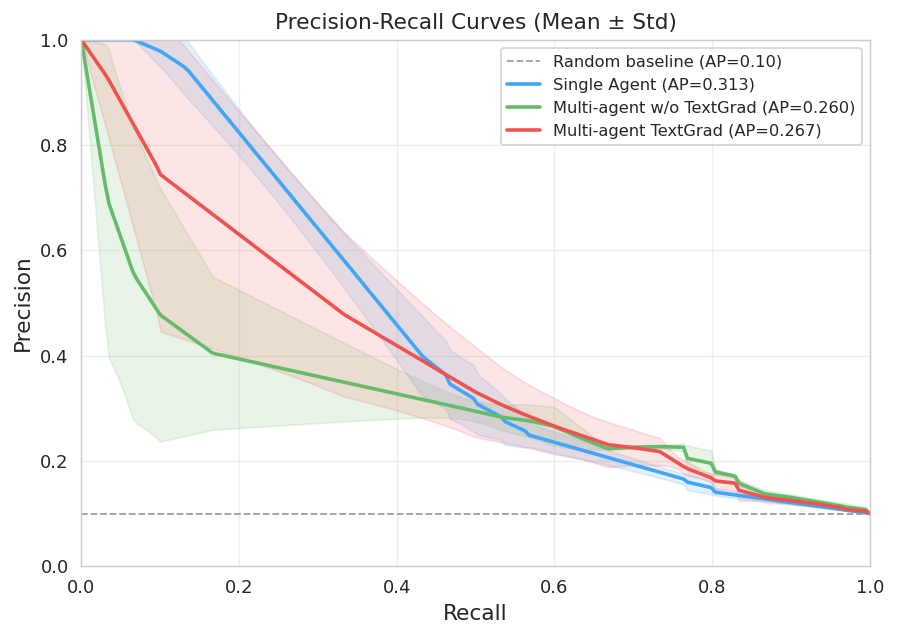

✓ Saved to results/pr_curves_test.pdf and .png


In [12]:
# ══════════════════════════════════════════════════════════════════════
# PR Curves — mean ± std across seeds (test split)
# ══════════════════════════════════════════════════════════════════════
import re
import json
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, average_precision_score

SPLIT = 'test'
RECALL_GRID = np.linspace(0, 1, 200)

COLORS = {'single': '#42A5F5', 'multi': '#66BB6A', 'textgrad': '#EF5350'}
LABELS = {
    'single': 'Single Agent',
    'multi': 'Multi-agent w/o TextGrad',
    'textgrad': 'Multi-agent TextGrad'
}

def load_preds_from_run(run_dir, condition, split):
    preds = list(run_dir.glob(f'{condition}_{split}_*_predictions.jsonl'))
    if not preds:
        return None, None
    rows = [json.loads(l) for l in preds[0].read_text().splitlines() if l.strip()]
    y_true = np.array([r['target'] for r in rows])
    y_prob  = np.array([r['probability_float'] for r in rows])
    return y_true, y_prob

fig, ax = plt.subplots(figsize=(7, 5))

# Random baseline at test base rate
ax.axhline(0.10, color='#9E9E9E', linestyle='--', linewidth=1,
           label='Random baseline (AP=0.10)')

for cond in ['single', 'multi', 'textgrad']:
    prec_curves, aps = [], [] # AP = Average Precision
    for ts in ABL_TIMESTAMP:
        run_dir = ABL_DIR / "runs" / ts
        y_true, y_prob = load_preds_from_run(run_dir, cond, SPLIT)
        if y_true is None:
            print(f"  ⚠  No {cond} {SPLIT} predictions in {ts}")
            continue
        prec, rec, _ = precision_recall_curve(y_true, y_prob)
        prec_curves.append(np.interp(RECALL_GRID, rec[::-1], prec[::-1]))
        aps.append(average_precision_score(y_true, y_prob))

    if not prec_curves:
        continue
    arr       = np.array(prec_curves)
    mean_prec = arr.mean(axis=0)
    std_prec  = arr.std(axis=0, ddof=1) if len(arr) > 1 else np.zeros_like(mean_prec)
    ax.plot(RECALL_GRID, mean_prec, color=COLORS[cond], linewidth=2,
            label=f'{LABELS[cond]} (AP={np.mean(aps):.3f})')
    ax.fill_between(RECALL_GRID, mean_prec - std_prec, mean_prec + std_prec,
                    alpha=0.15, color=COLORS[cond])

ax.set_xlabel('Recall', fontsize=12)
ax.set_ylabel('Precision', fontsize=12)
ax.set_title('Precision-Recall Curves (Mean \u00b1 Std)', fontsize=12) # Updated title
ax.legend(loc='upper right', fontsize=9)
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.grid(True, alpha=0.3)
plt.tight_layout()

out = PROJECT_ROOT / "results"
plt.savefig(out / "pr_curves_test.pdf", dpi=150, bbox_inches='tight')
plt.savefig(out / "pr_curves_test.png", dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved to results/pr_curves_test.pdf and .png")

## 6. LLM-as-judge: reasoning quality

Scores reasoning quality on 6 dimensions grounded in Schumpeter's innovation theory and VC evaluation criteria, across the single-agent, multi-analyst, and TextGrad conditions.

In [26]:
def _get_judge_run_dirs():
    """Resolve the judge results directories for the selected run(s)."""
    return _resolve_run_paths(JUDGE_DIR, RUN_TIMESTAMP, N_RECENT_RUNS)

def load_judge_data_for_runs(filename: str) -> list[Path]:
    """Return a list of paths to judge output files for the selected run(s)."""
    judge_run_dirs = _get_judge_run_dirs()
    if not judge_run_dirs:
        print(f"⚠  No Judge runs found for '{filename}'.")
        return []

    found_paths = []
    for d in judge_run_dirs:
        path = d / filename
        if path.exists():
            found_paths.append(path)
        else:
            print(f"⚠  Judge file '{filename}' not found in run {d.name}: {path}")

    # Handle legacy fallback if no files found in standard run dirs AND only one run was requested (or most recent)
    if not found_paths and (isinstance(RUN_TIMESTAMP, str) or RUN_TIMESTAMP is None):
        if filename == "judge_scores.jsonl":
            legacy = sorted(JUDGE_DIR.glob("judge_scores_*.jsonl"), key=lambda p: p.stat().st_mtime)
            if legacy:
                if isinstance(RUN_TIMESTAMP, str):
                    match = [f for f in legacy if RUN_TIMESTAMP in f.name]
                    if match:
                        found_paths.append(match[-1])
                elif RUN_TIMESTAMP is None:
                    found_paths.append(legacy[-1])

        elif filename == "judge_summary.json":
            legacy = sorted(JUDGE_DIR.glob("judge_summary_*.json"), key=lambda p: p.stat().st_mtime)
            if legacy:
                if isinstance(RUN_TIMESTAMP, str):
                    match = [f for f in legacy if RUN_TIMESTAMP in f.name]
                    if match:
                        found_paths.append(match[-1])
                elif RUN_TIMESTAMP is None:
                    found_paths.append(legacy[-1])
    return found_paths


def load_latest_judge_scores() -> pd.DataFrame | None:
    paths = load_judge_data_for_runs("judge_scores.jsonl")
    if not paths:
        return None

    all_dfs = []
    for path in paths:
        rows = [json.loads(l) for l in path.read_text().splitlines() if l.strip()]
        if rows:
            df = pd.DataFrame(rows)
            df['run_timestamp'] = path.parent.name
            all_dfs.append(df)
        print(f"Judge scores for run {path.parent.name} : {path.relative_to(PROJECT_ROOT)}  ({len(rows)} records)")

    if not all_dfs:
        return None

    combined_df = pd.concat(all_dfs, ignore_index=True)
    return combined_df

def load_latest_judge_summary() -> tuple[pd.DataFrame, pd.DataFrame] | None:
    paths = load_judge_data_for_runs("judge_summary.json")
    if not paths:
        return None, None

    all_summaries = []
    for path in paths:
        df_summary = pd.read_json(path)
        df_summary['run_timestamp'] = path.parent.name
        all_summaries.append(df_summary)
        print(f"Judge summary for run {path.parent.name} : {path.relative_to(PROJECT_ROOT)}")

    if not all_summaries:
        return None, None

    combined_summary = pd.concat(all_summaries)
    avg_summary = combined_summary.groupby(level=0).mean(numeric_only=True)
    return combined_summary, avg_summary

judge_df   = load_latest_judge_scores()
raw_judge_smry, judge_smry = load_latest_judge_summary()

print(f"Judge run directories used: {[d.name for d in _get_judge_run_dirs()]}")

Judge scores for run 2026-07-08_08-03-54 : results/judge_evaluation/runs/2026-07-08_08-03-54/judge_scores.jsonl  (30 records)
Judge scores for run 2026-07-08_12-42-49 : results/judge_evaluation/runs/2026-07-08_12-42-49/judge_scores.jsonl  (30 records)
Judge scores for run 2026-07-09_11-28-20 : results/judge_evaluation/runs/2026-07-09_11-28-20/judge_scores.jsonl  (30 records)
Judge scores for run 2026-07-10_08-11-25 : results/judge_evaluation/runs/2026-07-10_08-11-25/judge_scores.jsonl  (30 records)
Judge scores for run 2026-07-11_07-38-26 : results/judge_evaluation/runs/2026-07-11_07-38-26/judge_scores.jsonl  (30 records)
Judge summary for run 2026-07-08_08-03-54 : results/judge_evaluation/runs/2026-07-08_08-03-54/judge_summary.json
Judge summary for run 2026-07-08_12-42-49 : results/judge_evaluation/runs/2026-07-08_12-42-49/judge_summary.json
Judge summary for run 2026-07-09_11-28-20 : results/judge_evaluation/runs/2026-07-09_11-28-20/judge_summary.json
Judge summary for run 2026-07-1

In [28]:
display(raw_judge_smry)

,product novelty,market opportunity,feasibility,team quality,reasoning coherence,risk identification,total_score,run_timestamp
single,2.2,2.9,2.9,3.0,4.1,2.7,17.8,2026-07-08_08-03-54
multi,3.6,4.3,3.7,3.1,4.5,2.9,22.1,2026-07-08_08-03-54
textgrad,3.1,4.1,3.6,2.9,4.3,2.8,20.8,2026-07-08_08-03-54
single,2.7,2.9,2.9,3.5,4.0,2.8,18.8,2026-07-08_12-42-49
multi,3.4,4.3,3.7,3.2,4.5,3.1,22.2,2026-07-08_12-42-49
textgrad,3.3,4.1,3.5,3.0,4.4,2.9,21.2,2026-07-08_12-42-49
single,2.3,3.1,3.1,3.2,4.0,3.2,18.9,2026-07-09_11-28-20
multi,3.6,4.3,3.9,3.5,4.4,3.2,22.9,2026-07-09_11-28-20
textgrad,3.5,4.1,3.6,2.8,4.5,3.1,21.6,2026-07-09_11-28-20
single,2.4,3.0,2.7,2.9,4.2,2.5,17.7,2026-07-10_08-11-25


In [24]:
judge_smry

,product novelty,market opportunity,feasibility,team quality,reasoning coherence,risk identification,total_score
multi,3.42,4.28,3.72,3.16,4.48,3.08,22.14
single,2.30,2.96,2.86,3.12,4.00,2.74,17.98
textgrad,3.40,4.06,3.58,2.86,4.42,2.90,21.22


Average scores by condition (1–5 scale):



,product novelty,market opportunity,feasibility,team quality,reasoning coherence,risk identification,total_score
multi,3.42,4.28,3.72,3.16,4.48,3.08,22.14
single,2.30,2.96,2.86,3.12,4.00,2.74,17.98
textgrad,3.40,4.06,3.58,2.86,4.42,2.90,21.22


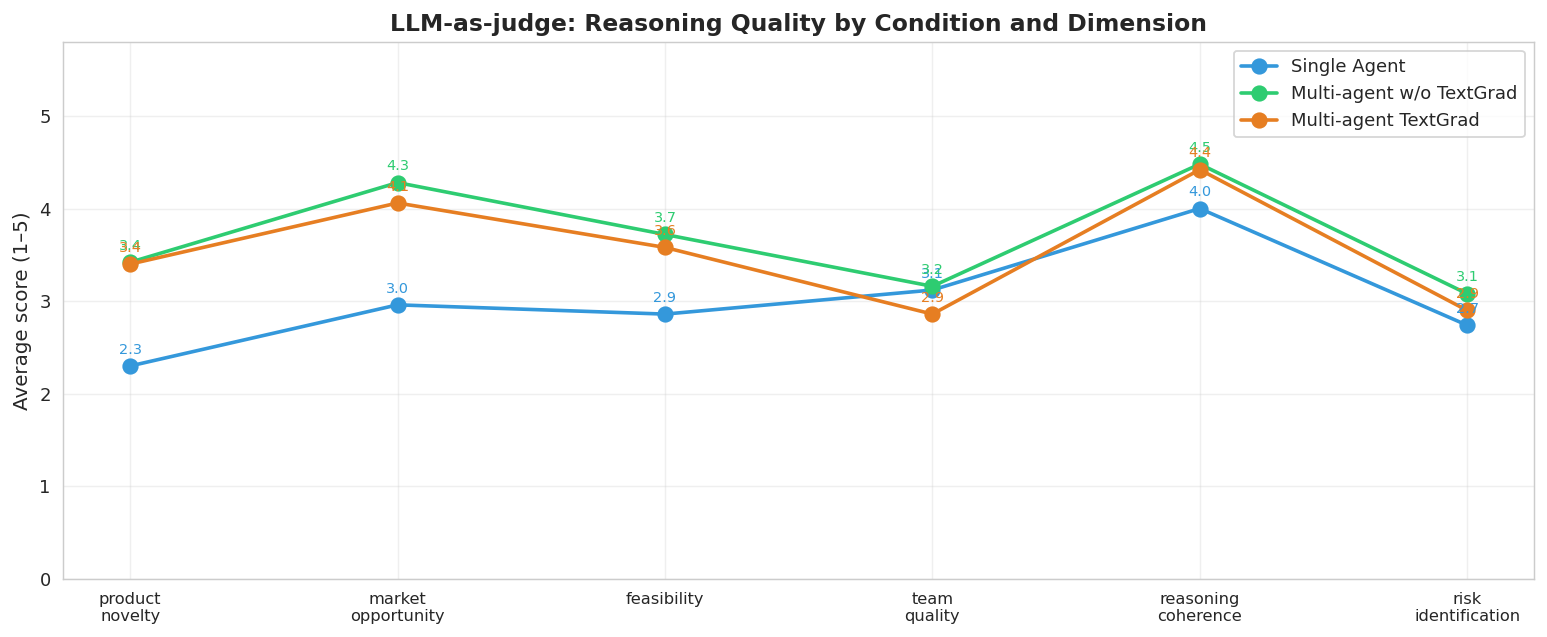

In [19]:
if judge_smry is not None:
    LABELS = {
        'single': 'Single Agent',
        'multi': 'Multi-agent w/o TextGrad',
        'textgrad': 'Multi-agent TextGrad'
    }
    palette = {'single':'#3498db','multi':'#2ecc71','textgrad':'#e67e22'}

    dims = ['product novelty','market opportunity','feasibility',
            'team quality','reasoning coherence','risk identification']
    available_dims = [d for d in dims if d in judge_smry.columns]

    print("Average scores by condition (1–5 scale):\n")
    display(judge_smry[available_dims + ['total_score']].round(2) if 'total_score' in judge_smry.columns
            else judge_smry[available_dims].round(2))

    order = [c for c in ['single','multi','textgrad'] if c in judge_smry.index]

    fig, ax = plt.subplots(figsize=(12, 5))
    x = np.arange(len(available_dims))

    for cond in order:
        vals = [judge_smry.loc[cond, d] if d in judge_smry.columns else 0 for d in available_dims]
        ax.plot(x, vals, 'o-', linewidth=2, markersize=8,
                label=LABELS[cond], color=palette.get(cond)) # Use new LABELS dict
        for xi, v in zip(x, vals):
            ax.text(xi, v + 0.1, f'{v:.1f}', ha='center', va='bottom', fontsize=8,
                    color=palette.get(cond))

    ax.set_xticks(x)
    ax.set_xticklabels([d.replace(' ', '\n') for d in available_dims], fontsize=9)
    ax.set_ylim(0, 5.8)
    ax.set_ylabel('Average score (1–5)')
    ax.set_title('LLM-as-judge: Reasoning Quality by Condition and Dimension', fontweight='bold') # Updated title
    ax.legend()
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("No judge results found. Run: python experiments/run_judge_evaluation.py --n_sample 10")

In [23]:
# Per-startup breakdown
if judge_df is not None and not judge_df.empty:
    score_cols = [c for c in judge_df.columns if c.endswith('_score')]
    print("Per-startup scores by condition:\n")
    for obj_id in judge_df['object_id'].unique():
        sub = judge_df[judge_df['object_id'] == obj_id]
        name   = sub['name'].iloc[0]
        target = 'INVEST' if sub['target'].iloc[0] == 1 else 'PASS'
        print(f"{name} (ground truth: {target})")
        for _, row in sub.iterrows():
            scores = '  '.join(f"{c.replace('_score','')[:4]}={int(row[c])}" for c in score_cols if c in row)
            print(f"  [{row['condition']:9s}] decision={str(row.get('decision','?')):5s}  {scores}  total={int(row['total_score'])}")
        print()

Per-startup scores by condition:

Cloudhopper (ground truth: INVEST)
  [single   ] decision=INVEST  prod=2  mark=4  feas=3  team=1  reas=4  risk=1  tota=15  total=15
  [multi    ] decision=INVEST  prod=4  mark=4  feas=4  team=2  reas=4  risk=3  tota=21  total=21
  [textgrad ] decision=INVEST  prod=3  mark=4  feas=4  team=2  reas=4  risk=3  tota=20  total=20
  [single   ] decision=INVEST  prod=2  mark=4  feas=3  team=2  reas=4  risk=4  tota=19  total=19
  [multi    ] decision=INVEST  prod=4  mark=4  feas=4  team=2  reas=4  risk=4  tota=22  total=22
  [textgrad ] decision=INVEST  prod=4  mark=4  feas=4  team=2  reas=4  risk=3  tota=21  total=21
  [single   ] decision=INVEST  prod=2  mark=4  feas=3  team=1  reas=4  risk=2  tota=16  total=16
  [multi    ] decision=INVEST  prod=4  mark=4  feas=4  team=2  reas=4  risk=3  tota=21  total=21
  [textgrad ] decision=INVEST  prod=4  mark=4  feas=4  team=2  reas=4  risk=3  tota=21  total=21
  [single   ] decision=INVEST  prod=3  mark=4  feas=2  tea

## 8. Score gains, radar chart, and progression

In [43]:
# ── Reload judge summary (safe if section 7 wasn't run) ──────────────────────
try:
    _smry = judge_smry
except NameError:
    _smry = None

if _smry is None:
    path = _pick_judge_file("judge_summary.json")
    _smry = pd.read_json(path) if path else None

DIMS = ['product novelty', 'market opportunity', 'feasibility',
        'team quality', 'reasoning coherence', 'risk identification']
DIMS = [d for d in DIMS if _smry is not None and d in _smry.columns]
ORDER = [c for c in ['single', 'multi', 'textgrad'] if _smry is not None and c in _smry.index]
PALETTE = {'single': '#3498db', 'multi': '#2ecc71', 'textgrad': '#e67e22'}

print(f"Conditions: {ORDER}")
print(f"Dimensions: {DIMS}")
if _smry is not None:
    display(_smry[DIMS + (['total_score'] if 'total_score' in _smry.columns else [])].round(2))

Conditions: ['single', 'multi', 'textgrad']
Dimensions: ['product novelty', 'market opportunity', 'feasibility', 'team quality', 'reasoning coherence', 'risk identification']


,product novelty,market opportunity,feasibility,team quality,reasoning coherence,risk identification,total_score
multi,3.42,4.28,3.72,3.16,4.48,3.08,22.14
single,2.30,2.96,2.86,3.12,4.00,2.74,17.98
textgrad,3.40,4.06,3.58,2.86,4.42,2.90,21.22


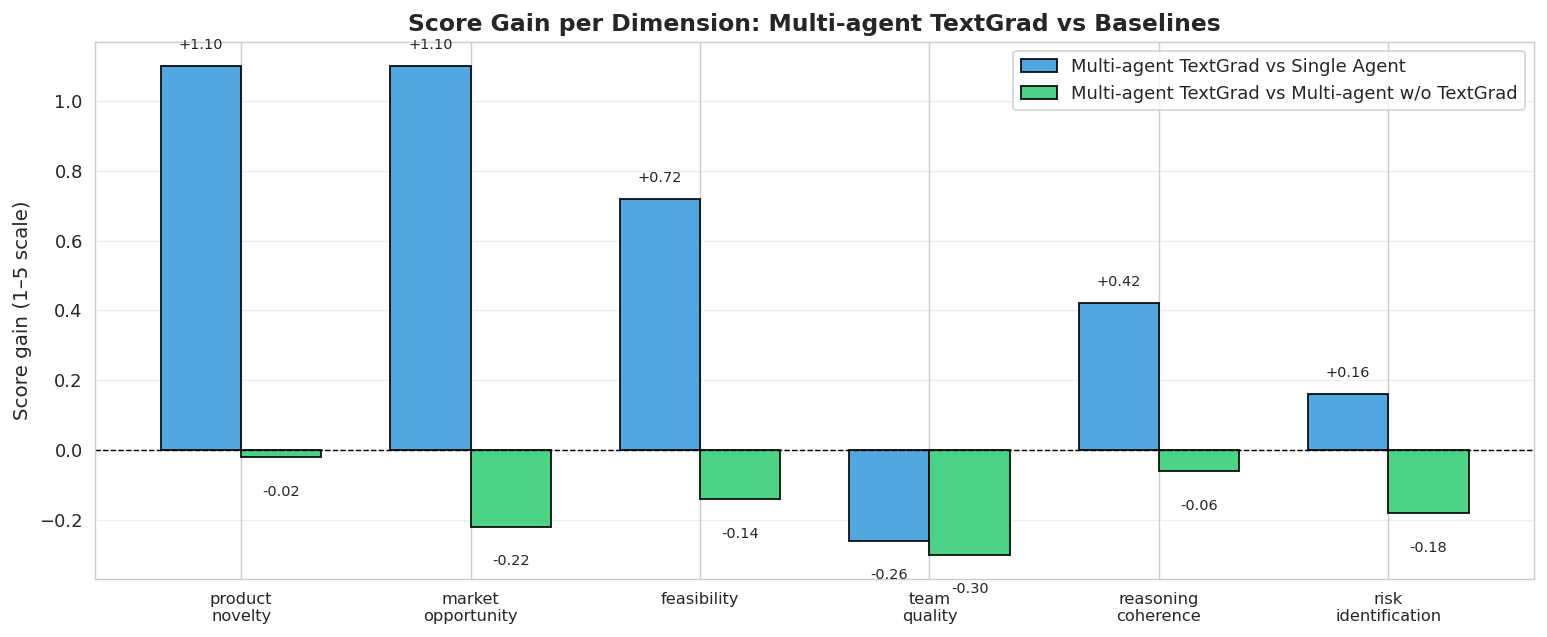

In [44]:
LABELS = {
    'single': 'Single Agent',
    'multi': 'Multi-agent w/o TextGrad',
    'textgrad': 'Multi-agent TextGrad'
}

PALETTE = {'single': '#3498db', 'multi': '#2ecc71', 'textgrad': '#e67e22'}

# ── Score gain per dimension ──────────────────────────────────────────────────
if _smry is not None and 'textgrad' in ORDER:
    fig, ax = plt.subplots(figsize=(12, 5))
    x = np.arange(len(DIMS))
    width = 0.35

    baseline_labels = {
        'single': f'{LABELS["textgrad"]} vs {LABELS["single"]}',
        'multi':  f'{LABELS["textgrad"]} vs {LABELS["multi"]}',
    }
    baselines = [c for c in ['single', 'multi'] if c in ORDER]
    offsets = np.linspace(-width/2 * (len(baselines)-1), width/2 * (len(baselines)-1), len(baselines))

    for offset, base in zip(offsets, baselines):
        deltas = [_smry.loc['textgrad', d] - _smry.loc[base, d] for d in DIMS]
        bars = ax.bar(x + offset, deltas, width, label=baseline_labels[base],
                      color=PALETTE[base], alpha=0.85, edgecolor='black', linewidth=1.1)
        for bar in bars:
            h = bar.get_height()
            ypos = h + 0.04 if h >= 0 else h - 0.12
            ax.text(bar.get_x() + bar.get_width()/2, ypos, f'{h:+.2f}',
                    ha='center', va='bottom', fontsize=8)

    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_xticks(x)
    ax.set_xticklabels([d.replace(' ', '\n') for d in DIMS], fontsize=9)
    ax.set_ylabel('Score gain (1–5 scale)')
    ax.set_title('Score Gain per Dimension: Multi-agent TextGrad vs Baselines', fontweight='bold') # Updated title
    ax.legend()
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

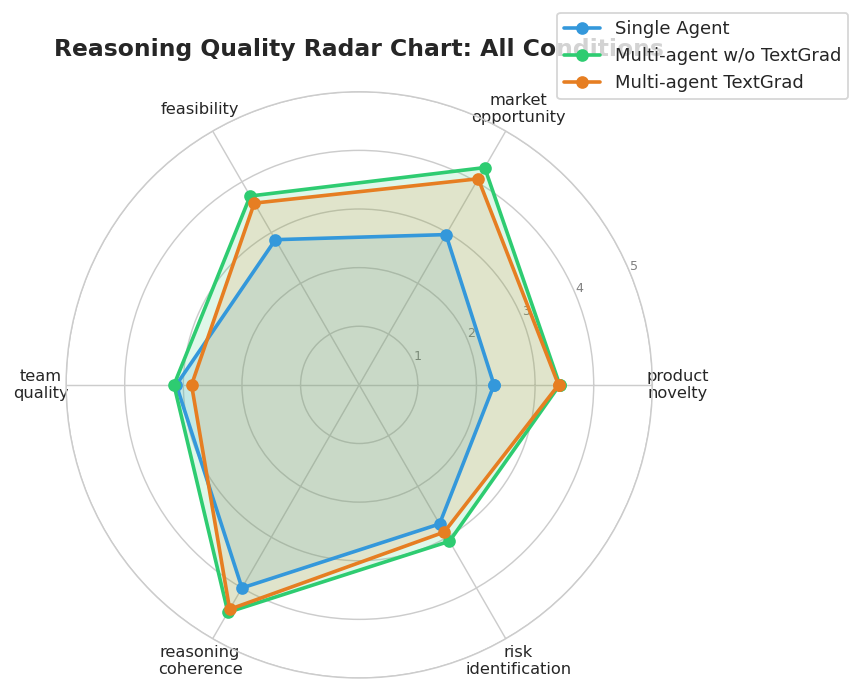

In [45]:
LABELS = {
    'single': 'Single Agent',
    'multi': 'Multi-agent w/o TextGrad',
    'textgrad': 'Multi-agent TextGrad'
}

PALETTE = {'single': '#3498db', 'multi': '#2ecc71', 'textgrad': '#e67e22'}

# ── Radar chart ───────────────────────────────────────────────────────────────
if _smry is not None:
    N = len(DIMS)
    angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
    angles += angles[:1]

    fig, ax = plt.subplots(figsize=(7, 7), subplot_kw={'projection': 'polar'})

    for cond in ORDER:
        vals = [_smry.loc[cond, d] for d in DIMS] + [_smry.loc[cond, DIMS[0]]]
        ax.plot(angles, vals, 'o-', linewidth=2, label=LABELS[cond], color=PALETTE[cond])
        ax.fill(angles, vals, alpha=0.15, color=PALETTE[cond])

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels([d.replace(' ', '\n') for d in DIMS], size=9)
    ax.set_ylim(0, 5)
    ax.set_yticks([1, 2, 3, 4, 5])
    ax.set_yticklabels(['1', '2', '3', '4', '5'], size=7, color='grey')
    ax.set_title('Reasoning Quality Radar Chart: All Conditions', fontweight='bold', pad=20)
    ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15))
    plt.tight_layout()
    plt.show()

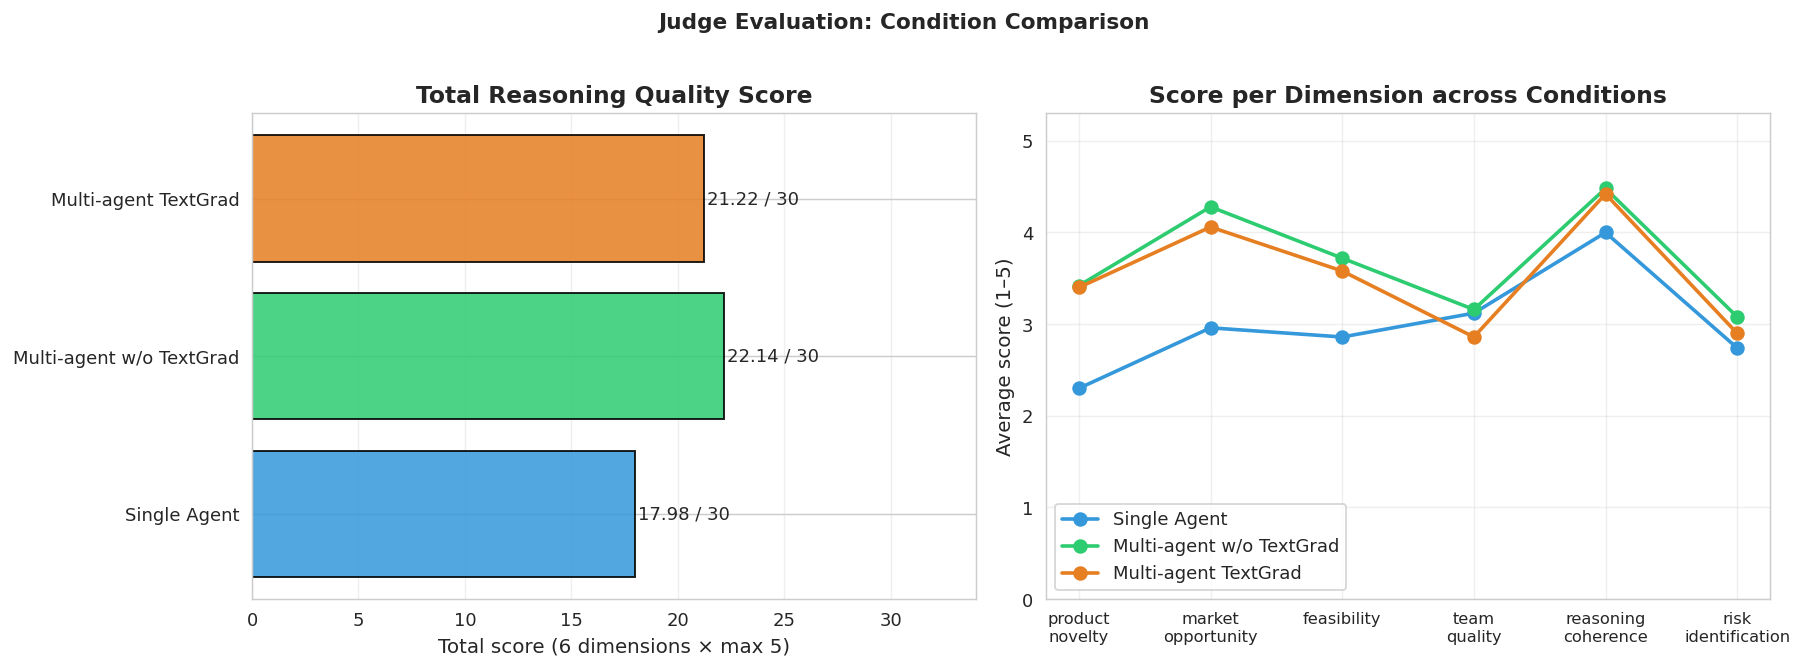

In [46]:
LABELS = {
    'single': 'Single Agent',
    'multi': 'Multi-agent w/o TextGrad',
    'textgrad': 'Multi-agent TextGrad'
}

PALETTE = {'single': '#3498db', 'multi': '#2ecc71', 'textgrad': '#e67e22'}

# ── Initial vs final total scores + per-dimension progression ─────────────────
if _smry is not None:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # Left: total score comparison
    if 'total_score' in _smry.columns:
        totals = [_smry.loc[c, 'total_score'] for c in ORDER]
        colors = [PALETTE[c] for c in ORDER]
        # Use new LABELS dict for bar labels
        bars = ax1.barh([LABELS[c] for c in ORDER], totals,
                        color=colors, alpha=0.85, edgecolor='black', linewidth=1.1)
        for bar, val in zip(bars, totals):
            ax1.text(val + 0.15, bar.get_y() + bar.get_height() / 2,
                     f'{val:.2f} / 30', va='center', fontsize=10)
        ax1.set_xlim(0, 34)
        ax1.set_xlabel('Total score (6 dimensions \u00d7 max 5)')
        ax1.set_title('Total Reasoning Quality Score', fontweight='bold')
        ax1.grid(axis='x', alpha=0.3)

    # Right: per-dimension score across conditions (line, treating as progression)
    x = np.arange(len(DIMS))
    for cond in ORDER:
        vals = [_smry.loc[cond, d] for d in DIMS]
        ax2.plot(x, vals, 'o-', linewidth=2, label=LABELS[cond],
                 color=PALETTE[cond], markersize=7)

    ax2.set_xticks(x)
    ax2.set_xticklabels([d.replace(' ', '\n') for d in DIMS], fontsize=9)
    ax2.set_ylim(0, 5.3)
    ax2.set_ylabel('Average score (1–5)')
    ax2.set_title('Score per Dimension across Conditions', fontweight='bold')
    ax2.legend()
    ax2.grid(alpha=0.3)

    plt.suptitle('Judge Evaluation: Condition Comparison', fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()